# BPY518 Lecture 6: Image Segmentation
Instructor: Josh Shaevitz  
Email: shaevitz@princeton.edu

## Lecture Outline
- Binary masks and segmentation pipelines
- Morphological operations and structuring elements
- Labeling connected components
- Measuring object properties and filtering objects
- Skeletons and boundaries
- Watershed splitting for touching objects

Segmentation means dividing an image into meaningful regions: cells, nuclei, vesicles, tissues, or any other objects we want to count and measure.

The slide deck frames segmentation as a pipeline:

1. Preprocess the image.
2. Threshold to get a binary mask.
3. Clean that mask with morphological operations.
4. Label the objects.
5. Measure and filter them.
6. Split touching objects if needed.

That is the structure this notebook follows.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import color, filters, measure, morphology, segmentation

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

media_dir = Path('media/Lecture_6')
rng = np.random.default_rng(12)

## Binary Masks

The first major goal in segmentation is to turn a grayscale image into a **binary mask**: foreground pixels are `1` and background pixels are `0`.

The source deck illustrates that progression on an E. coli image:

![Original image, binary mask, and labeled objects](media/Lecture_6/labeled_objects_example.png)

A mask is powerful because it turns image analysis into region analysis: once we know which pixels belong to a cell, we can label, count, and measure those pixels.

Otsu threshold: 0.431


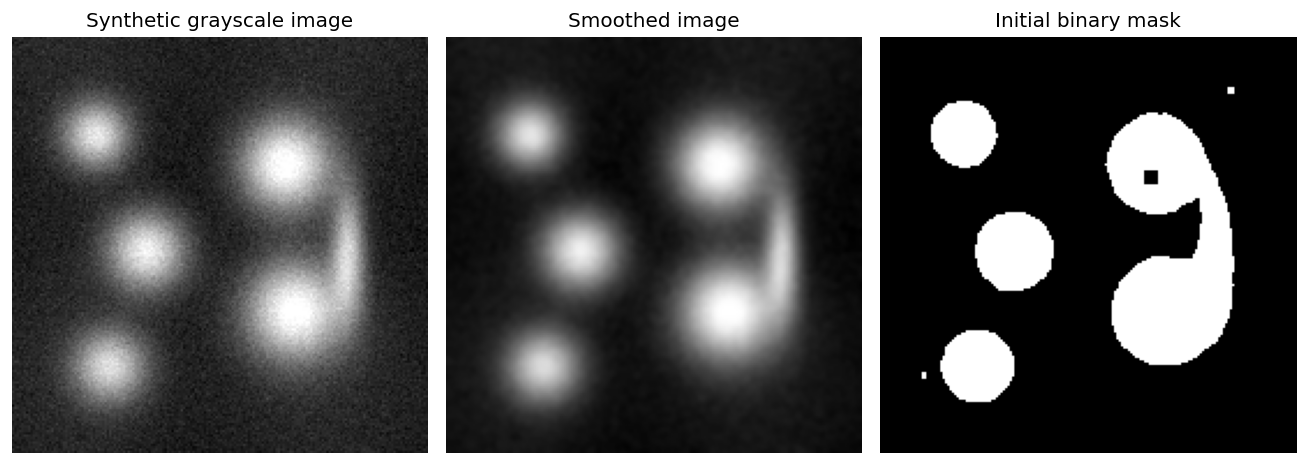

In [2]:
def make_segmentation_demo(shape=(180, 180), rng=None):
    yy, xx = np.mgrid[: shape[0], : shape[1]]
    image = 0.15 + 0.02 * np.sin(xx / 17) + 0.02 * np.cos(yy / 23)
    centers = [(42, 36), (55, 118), (92, 58), (118, 122), (142, 42)]
    radii = [10, 14, 12, 15, 11]
    amplitudes = [0.75, 0.9, 0.82, 0.88, 0.7]
    for (cy, cx), radius, amplitude in zip(centers, radii, amplitudes):
        image += amplitude * np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * radius**2))

    # Add one elongated bright artifact so filtering by shape later has something to remove.
    image += 0.65 * np.exp(-((xx - 145) ** 2) / (2 * 5**2)) * np.exp(-((yy - 92) ** 2) / (2 * 18**2))

    if rng is not None:
        image += 0.03 * rng.normal(size=shape)
    return np.clip(image, 0, 1)


demo_image = make_segmentation_demo(rng=rng)
smoothed = ndi.gaussian_filter(demo_image, sigma=1.2)
threshold = filters.threshold_otsu(smoothed)
initial_mask = smoothed > threshold

# Add a few artifacts to make morphological cleanup visible.
mask_with_artifacts = initial_mask.copy()
mask_with_artifacts[22:25, 150:153] = True
mask_with_artifacts[145:148, 18:20] = True
mask_with_artifacts[58:64, 114:120] = False

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
axes[0].imshow(demo_image)
axes[0].set_title('Synthetic grayscale image')
axes[0].axis('off')

axes[1].imshow(smoothed)
axes[1].set_title('Smoothed image')
axes[1].axis('off')

axes[2].imshow(mask_with_artifacts)
axes[2].set_title('Initial binary mask')
axes[2].axis('off')

plt.tight_layout()
print(f"Otsu threshold: {threshold:.3f}")

## Morphological Operations

Morphological operations modify the shape and connectivity of objects in a binary mask. The deck emphasizes the main ones:

- **Erosion** shrinks foreground objects.
- **Dilation** expands them.
- **Opening** = erosion then dilation.
- **Closing** = dilation then erosion.
- **Hole filling** repairs internal gaps.

These operations are defined by a **structuring element**: a small neighborhood such as a disk, square, or cross. Different structuring elements favor different geometric effects.

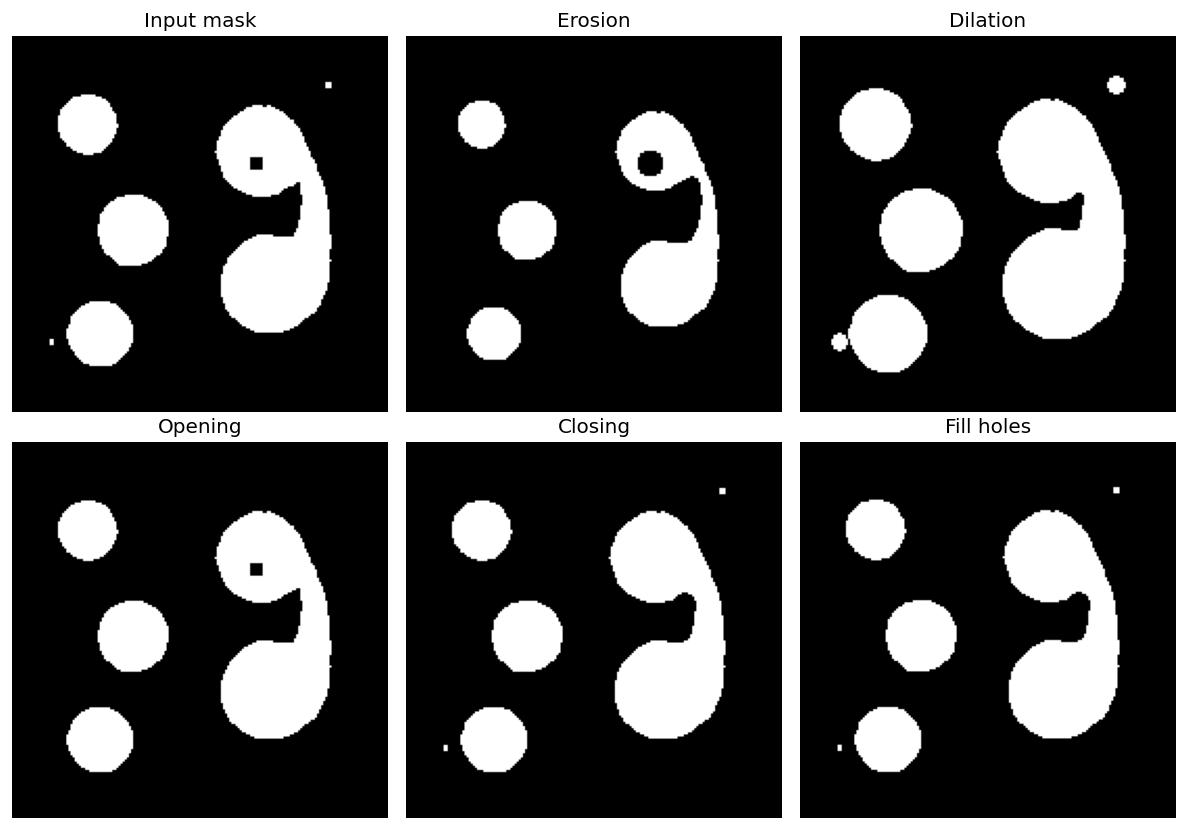

In [3]:
# Clean the mask with common morphological operations.
disk = morphology.disk(3)

eroded = ndi.binary_erosion(mask_with_artifacts, structure=disk)
dilated = ndi.binary_dilation(mask_with_artifacts, structure=disk)
opened = ndi.binary_opening(mask_with_artifacts, structure=disk)
closed = ndi.binary_closing(mask_with_artifacts, structure=disk)
filled = ndi.binary_fill_holes(closed)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
examples = [
    ('Input mask', mask_with_artifacts),
    ('Erosion', eroded),
    ('Dilation', dilated),
    ('Opening', opened),
    ('Closing', closed),
    ('Fill holes', filled),
]
for ax, (title, image) in zip(axes.flat, examples):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()

Opening is often useful for removing small specks and breaking thin bridges. Closing is useful for sealing small gaps and smoothing contours. Hole filling is especially common once we are confident that object interiors should be solid.

## Labeling Connected Components

Once a mask is clean enough, we can turn it into explicit objects by assigning each connected component its own integer label.

That is the moment when “foreground pixels” become “cell 1”, “cell 2”, and so on.

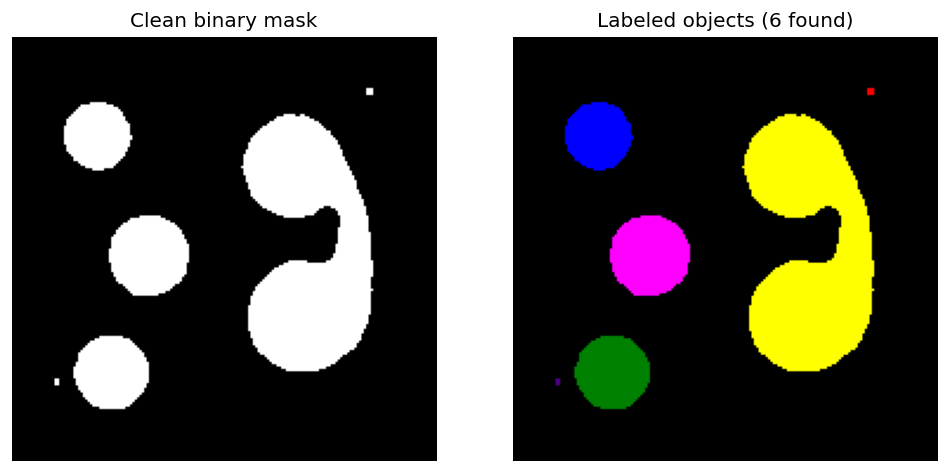

In [4]:
# Label connected objects.
labeled_mask, num_objects = ndi.label(filled)
label_rgb = color.label2rgb(labeled_mask, bg_label=0, bg_color=(0, 0, 0))

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
axes[0].imshow(filled)
axes[0].set_title('Clean binary mask')
axes[0].axis('off')

axes[1].imshow(label_rgb)
axes[1].set_title(f'Labeled objects ({num_objects} found)')
axes[1].axis('off')

plt.tight_layout()

## Measuring Region Properties

After labeling, we can compute features for each object: area, centroid, perimeter, eccentricity, orientation, intensity, and more. That turns segmentation into a quantitative dataset.

In [5]:
# Measure a few properties from each segmented object.
props_table = measure.regionprops_table(
    labeled_mask,
    intensity_image=smoothed,
    properties=('label', 'area', 'centroid', 'eccentricity', 'perimeter', 'mean_intensity'),
)
props_df = pd.DataFrame(props_table)
props_df.round(2)

,label,area,centroid-0,centroid-1,eccentricity,perimeter,mean_intensity
0,1,9.0,23.00,151.00,0.00,8.00,0.18
1,2,644.0,41.78,35.70,0.19,92.67,0.63
2,3,3952.0,89.43,125.39,0.90,352.63,0.67
3,4,922.0,92.47,57.51,0.14,110.91,0.65
4,5,783.0,142.02,41.68,0.10,100.91,0.61
5,6,6.0,146.00,18.50,0.79,6.00,0.25


## Filtering Objects by Property

The slide deck points out that segmentation does not end at “find everything.” We often want to keep only objects with plausible size or shape.

For example, if we want roughly cell-like objects, we might require a minimum area and reject very elongated artifacts.

Kept labels: [2, 4, 5]


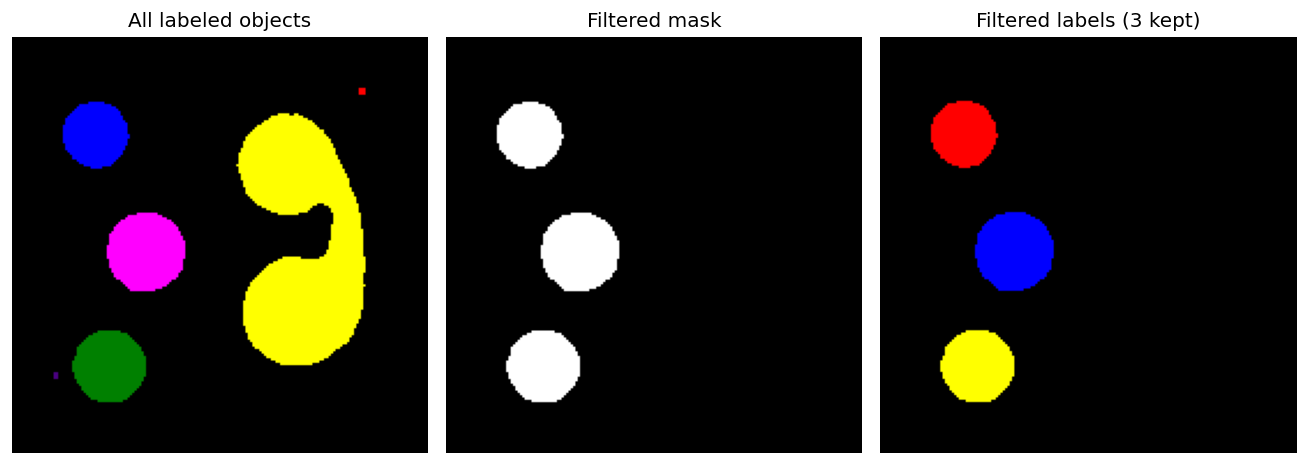

In [6]:
# Keep only objects that look like the intended cells.
keep_labels = props_df.loc[
    (props_df['area'] > 250) & (props_df['eccentricity'] < 0.85),
    'label',
].to_numpy()
filtered_mask = np.isin(labeled_mask, keep_labels)
filtered_labels, filtered_count = ndi.label(filtered_mask)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
axes[0].imshow(label_rgb)
axes[0].set_title('All labeled objects')
axes[0].axis('off')

axes[1].imshow(filtered_mask)
axes[1].set_title('Filtered mask')
axes[1].axis('off')

axes[2].imshow(color.label2rgb(filtered_labels, bg_label=0, bg_color=(0, 0, 0)))
axes[2].set_title(f'Filtered labels ({filtered_count} kept)')
axes[2].axis('off')

plt.tight_layout()
print('Kept labels:', keep_labels.tolist())

## Skeletons and Boundaries

Sometimes we do not need the full mask area. Instead we may want:

- a **skeleton**, which reduces each object to a 1-pixel-wide centerline, or
- the **boundary**, which keeps only the contour.

The source deck shows both representations on bacterial masks:

![Skeleton example](media/Lecture_6/skeleton_example.png)

![Boundary overlay example](media/Lecture_6/boundary_overlay_example.png)

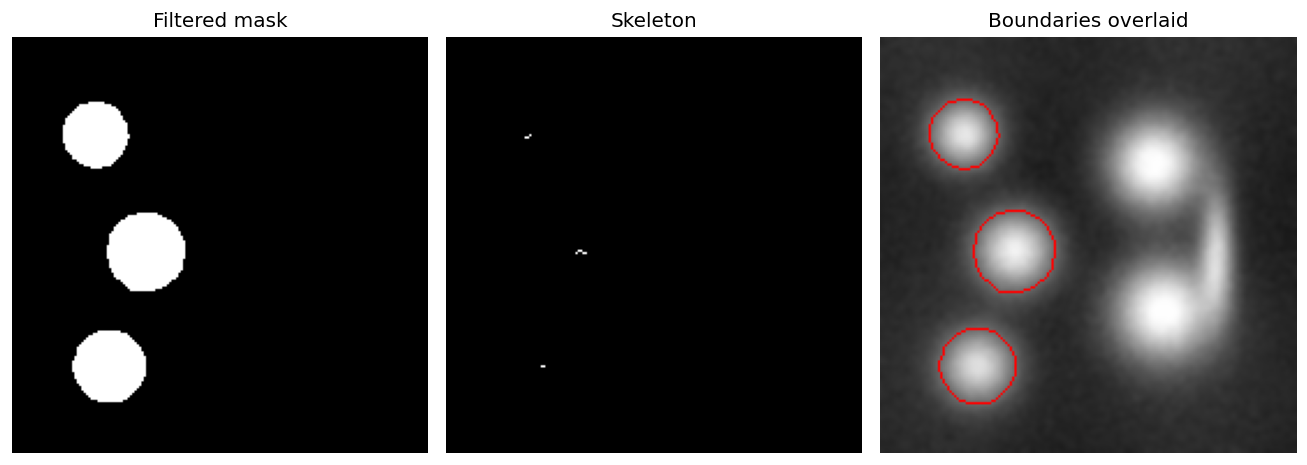

In [7]:
# Extract skeletons and boundaries from the filtered mask.
skeleton = morphology.skeletonize(filtered_mask)
boundaries = segmentation.find_boundaries(filtered_mask, mode='outer')

boundary_overlay = np.dstack([smoothed, smoothed, smoothed])
boundary_overlay[..., 0] = np.maximum(boundary_overlay[..., 0], boundaries.astype(float))
boundary_overlay[..., 1] *= ~boundaries
boundary_overlay[..., 2] *= ~boundaries

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
axes[0].imshow(filtered_mask)
axes[0].set_title('Filtered mask')
axes[0].axis('off')

axes[1].imshow(skeleton)
axes[1].set_title('Skeleton')
axes[1].axis('off')

axes[2].imshow(boundary_overlay)
axes[2].set_title('Boundaries overlaid')
axes[2].axis('off')

plt.tight_layout()

## Touching Objects and Watershed Splitting

Thresholding alone often merges nearby cells into one connected component. The classic fix is a watershed workflow:

1. Compute the distance transform inside the binary mask.
2. Find local maxima that serve as object centers.
3. Use those maxima as markers.
4. Run watershed on the negative distance map.

The source deck shows three stages of that pipeline:

![Distance transform example](media/Lecture_6/watershed_distance_transform.png)

![Watershed markers](media/Lecture_6/watershed_markers.png)

![Final watershed segmentation](media/Lecture_6/watershed_final.png)

Watershed markers found: 5


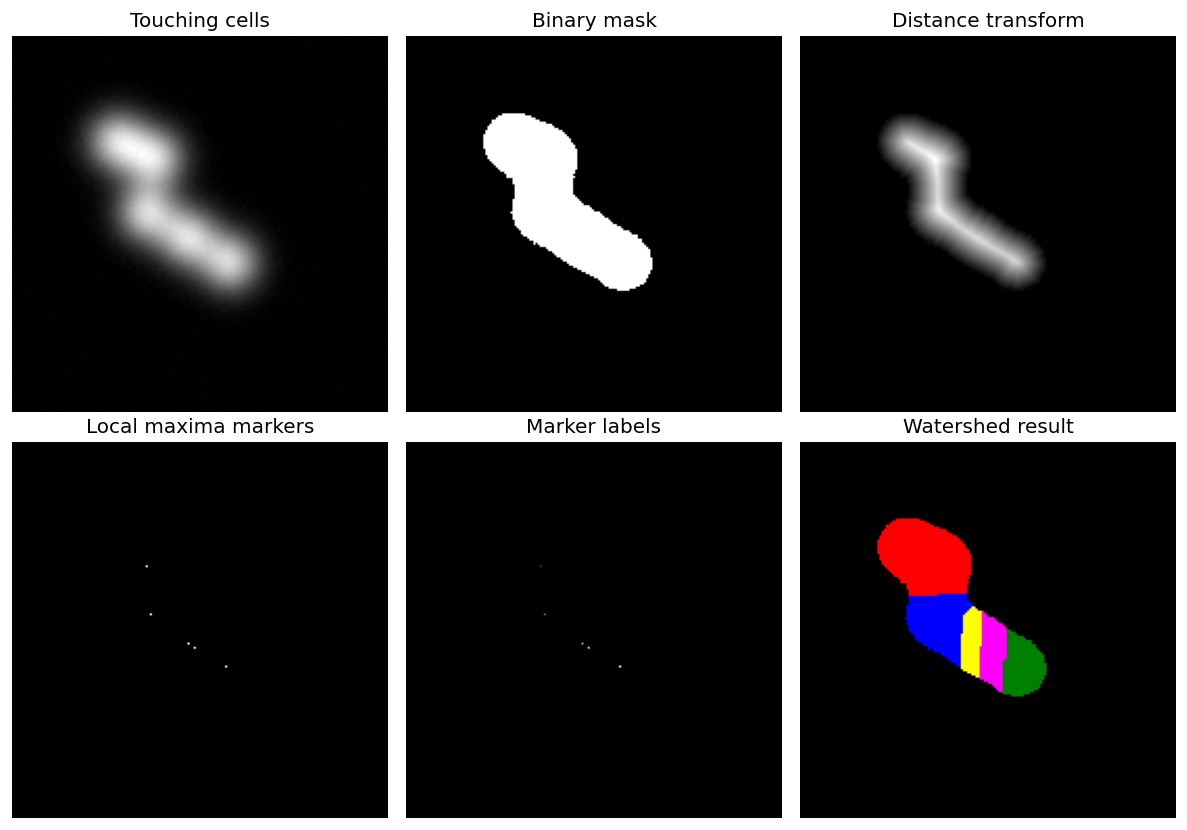

In [8]:
# Build a synthetic example with overlapping cells and split them by watershed.
yy, xx = np.mgrid[:180, :180]
touching_image = np.zeros((180, 180), dtype=float)
for cy, cx, sigma in [(50, 50, 10), (58, 68, 10), (84, 64, 10), (96, 84, 10), (108, 104, 10)]:
    touching_image += np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma**2))
touching_image += 0.01 * np.random.default_rng(123).normal(size=touching_image.shape)
touching_image = np.clip(touching_image, 0, None)

mask_touching = touching_image > filters.threshold_otsu(touching_image)
distance = ndi.distance_transform_edt(mask_touching)
peak_response = ndi.maximum_filter(distance, size=13)
local_max = (distance == peak_response) & (distance > 5)
markers, marker_count = ndi.label(local_max)
watershed_labels = segmentation.watershed(-distance, markers, mask=mask_touching)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
views = [
    ('Touching cells', touching_image),
    ('Binary mask', mask_touching),
    ('Distance transform', distance),
    ('Local maxima markers', local_max),
    ('Marker labels', markers),
    ('Watershed result', color.label2rgb(watershed_labels, bg_label=0, bg_color=(0, 0, 0))),
]
for ax, (title, image) in zip(axes.flat, views):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
print(f'Watershed markers found: {marker_count}')

## Key Points

- Segmentation usually starts by converting an image into a binary mask.
- Morphological operations repair, simplify, and regularize masks.
- Connected-component labeling turns masks into countable objects.
- Region properties let us measure and filter objects quantitatively.
- Skeletons and boundaries are alternative representations of the same segmented regions.
- Watershed is a standard way to split touching objects once a binary mask has merged them.